# Applying DeepRV to IPMs
In this notebook, we investigate how the time cost of **DeepRV** with data from a Gaussian process. We use simulated data of size n = 250, 500, 750, 1,000.

The data are simulated with the vital rates modelled as GPs instead of GLMs.

As with before, let $s \in \mathbb{R}^n$ denote a fixed set of input points, and let $k_{\theta}(\cdot,\cdot)$ be a kernel function with parameters $\theta$. We assume

$$
f(s) \sim \mathcal{GP}(0, K_{\theta}),
\qquad
(K_{\theta})_{ij} = k_{\theta}(s_i, s_j).
$$

Equivalently, a draw from the Gaussian process can be written as

$$
f(s) = L_{\theta} z,
\qquad
z \sim \mathcal{N}(0, I_n),
\qquad
L_{\theta} = \mathrm{chol}(K_{\theta}).
$$

Since the Cholesky decomposition of an $n \times n$ matrix scales as $O(n^3)$, we hope to train a neural network that provides a faster approximation:

$$
\mathrm{DeepRV}(\theta, z) \approx f(s).
$$

We use the gMLP formulation of DeepRV adapted from dl4bi/benchmarks/vae/deep_rv_example.py

This means that the input 'locations' to the network are fixed. We therefore will use the full vector of sizes, s, as the input to the network.

[For constructing an IPM, we will need to evaluate the $f(.)$ at mesh points when discretizing the kernel, hence we will also include these points in the input].

We consider as an example the survival model, where the hierarchy is

$$
\theta \sim p(\theta),
$$

$$
f(s') \mid \theta \sim \mathcal{GP}(0, K_{\theta})

$$

$$
y \sim \mathrm{Bernoulli}\left(\sigma\left(f(s')\right)\right),
$$

where $\sigma(\cdot)$ is the logistic sigmoid function. 

Note that $s$ in this context does not include all observations but only those for which 'surv' $\neq$ na, where 'surv' could be na because the plant flowered which meant certain death. This is generally true for vital rates, in that we will not use the full vector of sizes for inference. Hence when using DeepRV for GP computations, $$\mathrm{DeepRV}(\theta, z) \approx f(s)$$, we must subset the vector appropriately in our HMC scheme.

The target posterior is

$$
p(\theta, f \mid y)
\propto
p(\theta), p(f \mid \theta), p(y \mid f, \theta).
$$

During inference, we draw samples from this posterior using HMC. At each iteration of HMC, given the current state $(\theta, f)$, we must evaluate the log posterior:

$$
\log p(\theta, f \mid y)
=

\log p(\theta)
+
\log p(f \mid \theta)
+
\log p(y \mid f, \theta).
$$

Since $f$ depends on the Gaussian process draw, computing it directly requires the Cholesky decomposition, which is expensive. DeepRV is intended to replace this costly step with a faster neural network approximation.

Adapting the DeepRV code, we attempt to perform inference using a trained DeepRV network instead of repeatedly performing Cholesky factorisations.


In [1]:
import sys

sys.path.append("benchmarks/vae")

from pathlib import Path
from typing import Callable, Optional, Union
import jax
import time
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import optax
from jax import Array, jit, random
from numpyro import distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, init_to_median
from dl4bi_sps.kernels import rbf
from dl4bi_sps.utils import build_grid
from utils.plot_utils import plot_infer_trace

import wandb
from dl4bi.core.model_output import VAEOutput
from dl4bi.core.train import cosine_annealing_lr, train
from dl4bi.vae import gMLPDeepRV
from dl4bi.vae.train_utils import deep_rv_train_step, generate_surrogate_decoder

from deeprv_utils import hmc, gen_train_dataloader, inference_model, valid_step, train_deeprv, run_gp_inference, run_deeprv_inference, compute_metrics

/opt/anaconda3/envs/dl4bi-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
priors = {
    "ls": dist.HalfNormal(5.0), 
    "r":dist.HalfNormal(5.0)
    }

wandb.init(mode="disabled")

In [5]:
dataset_sizes = [250]  #,500,750,1000]
datasets = {}

for n in dataset_sizes:
    datasets[n] = pd.read_csv(f"gp_sample{n}.csv")
    print(datasets[n].head())
    print(f"\nShape: {datasets[n].shape}\n")
    print(datasets[n].describe())

       id  year         z  age  survived  reproduced  n_seeds
0  445141    39  1.068144    2       1.0           0      NaN
1  110162    28  0.071170    0       0.0           0      NaN
2  266958    34  1.331782    1       1.0           0      NaN
3  327160    35 -1.156128    0       0.0           0      NaN
4  367965    37  1.078800    1       0.0           0      NaN

Shape: (250, 7)

                  id        year           z         age    survived  \
count     250.000000  250.000000  250.000000  250.000000  239.000000   
mean   352209.496000   34.220000    0.513948    0.692000    0.464435   
std    201441.761066    5.854631    1.112116    1.139443    0.499780   
min      5514.000000    8.000000   -1.843070    0.000000    0.000000   
25%    174347.750000   31.000000   -0.281761    0.000000    0.000000   
50%    342747.000000   36.000000    0.418685    0.000000    0.000000   
75%    522540.000000   39.000000    1.227178    1.000000    1.000000   
max    726313.000000   40.000000  

In [ ]:
def generate_survival_data(dataset):
    subset = dataset.loc[dataset["Repr"] == 0,["z", "Surv"]].dropna()

    subset["z"] = subset["z"].astype("float32")
    subset["Surv"] = subset["Surv"].astype("float32")

    surv_data_jnp = jnp.asarray(
        subset.to_numpy(dtype="float32")
    )

    s_surv = surv_data_jnp[:, 0:1]
    y_surv = surv_data_jnp[:, 1]

    return s_surv, y_surv

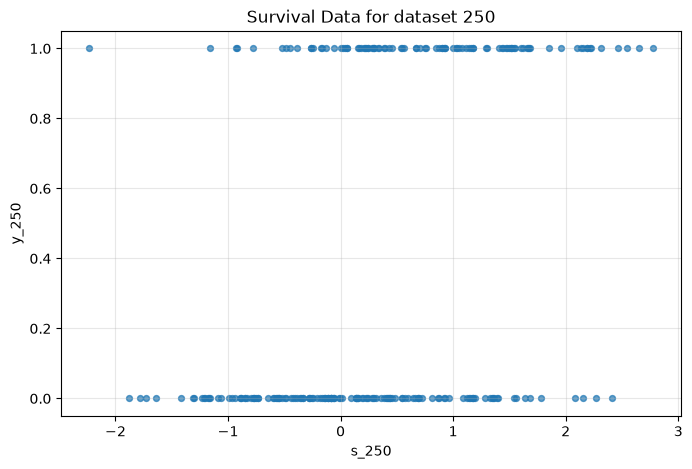

In [18]:
s_250, y_250 = generate_survival_data(datasets[250])

plt.figure(figsize=(8, 5))
plt.scatter(s_250, y_250, s=18, alpha=0.7)

plt.title("Survival Data for dataset 250")
plt.xlabel("s_250")
plt.ylabel("y_250")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
"""""
Checks shape of likelihood. Previously, y was a (N,1) vector while p was a (N,) scalar. As a result, 
numpyro.sample("obs", dist.Bernoulli(probs=p), obs=y) broadcasts into an (N x N) matrix, which 
violates the Bernoulli Model
"""

from numpyro import handlers

priors_test = {
    "ls": dist.HalfNormal(5.0),
    "r": dist.HalfNormal(5.0),
}

def inspect_obs_shape(y):
    seeded_model = handlers.seed(model, rng_seed=0)
    tr = handlers.trace(seeded_model).get_trace(
        surrogate_decoder=None,
        obs_mask=True,
        y=y,
    )

    obs_site = tr["obs"]
    print("y shape:", y.shape)
    print("obs value shape:", obs_site["value"].shape)
    print("obs fn batch shape:", obs_site["fn"].batch_shape)

    log_prob = obs_site["fn"].log_prob(obs_site["value"])
    print("obs log_prob shape:", log_prob.shape)
    print()

s, y = generate_survival_data(datasets[250])

print("s shape:", s.shape)
print("y shape:", y.shape)

model = inference_model(s[:5], priors)

inspect_obs_shape(y[:5])
inspect_obs_shape(y[:5].squeeze())

"""
Expected: 
s shape: (237, 1)
y shape: (237,)

y shape: (5,)
obs value shape: (5,)
obs fn batch shape: (5,)
obs log_prob shape: (5,)

y shape: (5,)
obs value shape: (5,)
obs fn batch shape: (5,)
obs log_prob shape: (5,)
"""


s shape: (237, 1)
y shape: (237,)
y shape: (5,)
obs value shape: (5,)
obs fn batch shape: (5,)
obs log_prob shape: (5,)

y shape: (5,)
obs value shape: (5,)
obs fn batch shape: (5,)
obs log_prob shape: (5,)



'\nExpected: \ns shape: (237, 1)\ny shape: (237,)\n\ny shape: (5,)\nobs value shape: (5,)\nobs fn batch shape: (5,)\nobs log_prob shape: (5,)\n\ny shape: (5,)\nobs value shape: (5,)\nobs fn batch shape: (5,)\nobs log_prob shape: (5,)\n'

## Testing 

In [6]:
s, y = generate_survival_data(datasets[250])

s_small = s[:30]
y_small = y[:30]

print("s_small:", s_small.shape)
print("y_small:", y_small.shape)

s_small: (30, 1)
y_small: (30,)


In [7]:
def hmc_smoke(rng, model, y_obs, obs_mask=True, surrogate_decoder=None):
    nuts = NUTS(model, init_strategy=init_to_median(num_samples=5))
    mcmc = MCMC(
        nuts,
        num_chains=1,
        num_samples=100,
        num_warmup=100,
        progress_bar=True,
    )

    start = time.perf_counter()
    mcmc.run(
        rng,
        surrogate_decoder=surrogate_decoder,
        obs_mask=obs_mask,
        y=y_obs,
    )
    elapsed = time.perf_counter() - start

    samples = mcmc.get_samples()
    return samples, mcmc, elapsed

In [8]:
rng = random.key(0)
model = inference_model(s_small, priors)

gp_samples, gp_mcmc, gp_time = hmc_smoke(
    rng,
    model,
    y_small,
    obs_mask=True,
)

print("GP smoke time:", gp_time)
print("mu shape:", gp_samples["mu"].shape)
print("ls mean:", gp_samples["ls"].mean())
print("r mean:", gp_samples["r"].mean())
"""
Expected: mu shape: (100, 30)
"""

sample: 100%|██████████| 200/200 [00:02<00:00, 87.51it/s, 15 steps of size 2.60e-01. acc. prob=0.91] 


GP smoke time: 10.199886583955958
mu shape: (100, 30)
ls mean: 3.889353
r mean: 3.6840508


'\nExpected: mu shape: (100, 30)\n'

In [9]:
rng = random.key(1)
rng_train, rng_deeprv = random.split(rng)

surrogate_decoder, train_time, state = train_deeprv(
    rng_train,
    s_small,
    priors,
    num_steps=500,   # tiny smoke-test training
)

print("DeepRV smoke train time:", train_time)

deeprv_samples, deeprv_mcmc, deeprv_time = hmc_smoke(
    rng_deeprv,
    model,
    y_small,
    obs_mask=True,
    surrogate_decoder=surrogate_decoder,
)

print("DeepRV smoke inference time:", deeprv_time)
print("DeepRV mu shape:", deeprv_samples["mu"].shape)

"""
Expected : DeepRV mu shape: (100, 30)
"""


                               gMLPDeepRV Summary                               
┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ path     ┃ module   ┃ inputs   ┃ outputs   ┃ flops    ┃ vjp_flops ┃ params   ┃
┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│          │ gMLPDee… │ conditi… │ encoder_… │ 1654780… │ 493898208 │          │
│          │          │ float32… │   obj:    │          │           │          │
│          │          │ f:       │ None      │          │           │          │
│          │          │ float32… │ f_hat:    │          │           │          │
│          │          │ s:       │   dtype:  │          │           │          │
│          │          │ float32… │ dtype(fl… │          │           │          │
│          │          │ z:       │   shape:  │          │           │          │
│          │          │ float32… │   - 32    │          │           │          │
│          │          │    

100%|██████████| 500/500 [00:19<00:00, 25.53batch/s, Train Loss=0.7630]


DeepRV smoke train time: 32.62931587500498


sample: 100%|██████████| 200/200 [00:07<00:00, 28.05it/s, 7 steps of size 4.67e-01. acc. prob=0.86] 

DeepRV smoke inference time: 9.091173792025074
DeepRV mu shape: (100, 30)


'\nExpected : DeepRV mu shape: (100, 30)\n'

## Saving Trained DeepRV Models

The scaling experiment trains a new DeepRV surrogate for each dataset size. By default, the trained neural network only exists in memory during the notebook run. Once the function finishes, the trained parameters are lost unless we explicitly save them.

The code below saves the trained DeepRV `TrainState` after training. This state contains the learned neural-network parameters, optimizer state, and any additional model variables needed to reconstruct the surrogate decoder later.

For each dataset size, the checkpoint is saved under:

```text
results/deeprv_scaling/N_<dataset_size>/model.ckpt

In [10]:
import json
from pathlib import Path
from omegaconf import DictConfig
from dl4bi.core.train import save_ckpt

In [11]:
def save_deeprv_training_output(
    state,
    save_dir,
    *,
    dataset_size,
    train_time,
    num_train_steps,
    s_shape,
    y_shape,
    model_name="gMLPDeepRV",
):
    """
    Save a trained DeepRV model state and lightweight run metadata.

    Parameters
    ----------
    state:
        Trained Flax TrainState returned by ``train_deeprv``. This contains the
        learned neural-network parameters and any non-parameter model variables.

    save_dir : str or pathlib.Path
        Directory where the checkpoint and metadata should be written.

    dataset_size : int
        Number of observations/locations used in this scaling run.

    train_time : float
        Wall-clock training time in seconds.

    num_train_steps : int
        Number of optimization steps used to train DeepRV.

    s_shape : tuple
        Shape of the location matrix. Expected shape is ``(N, spatial_dim)``.

    y_shape : tuple
        Shape of the response vector. Expected shape is ``(N,)``.

    model_name : str
        Human-readable model identifier for the metadata file.

    Returns
    -------
    pathlib.Path
        Path to the saved checkpoint directory.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    ckpt_path = save_dir / "model.ckpt"
    metadata_path = save_dir / "metadata.json"

    # The repo's checkpoint helper saves the full TrainState as an Orbax PyTree.
    save_ckpt(state, DictConfig({}), ckpt_path)

    metadata = {
        "model_name": model_name,
        "dataset_size": int(dataset_size),
        "train_time_seconds": float(train_time),
        "num_train_steps": int(num_train_steps),
        "s_shape": list(s_shape),
        "y_shape": list(y_shape),
        "checkpoint_path": str(ckpt_path),
    }

    with metadata_path.open("w") as f:
        json.dump(metadata, f, indent=2)

    return ckpt_path

In [12]:
def save_mcmc_outputs(
    samples,
    posterior_predictive,
    save_dir,
    *,
    model_label,
    dataset_size,
    inference_time,
    seed,
):
    """
    Save MCMC posterior samples and posterior predictive draws to disk.

    Parameters
    ----------
    samples : dict
        Dictionary returned by ``mcmc.get_samples()``. Each key is a sampled
        variable name, such as ``"ls"``, ``"r"``, ``"z"``, or ``"mu"``.

    posterior_predictive : array-like
        Posterior predictive draws returned by ``Predictive(...)``. In this
        notebook, this is usually simulated Bernoulli observations generated
        from posterior samples.

    save_dir : str or pathlib.Path
        Folder where the MCMC outputs should be saved.

    model_label : str
        Short name for the inference method, for example ``"gp"`` or
        ``"deeprv"``.

    dataset_size : int
        Number of observations/locations used in this inference run.

    inference_time : float
        Wall-clock inference time in seconds.

    seed : int
        Random seed used for this inference run.

    Returns
    -------
    pathlib.Path
        Path to the saved ``.npz`` file containing posterior arrays.

    Notes
    -----
    The samples are saved as a compressed NumPy ``.npz`` file. This is a common
    format for storing multiple named arrays in one file.

    The metadata is saved separately as a JSON file, which is a readable text
    file containing labels and values.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    samples_path = save_dir / f"{model_label}_mcmc_samples.npz"
    metadata_path = save_dir / f"{model_label}_mcmc_metadata.json"

    # Convert JAX arrays to NumPy arrays so they can be saved reliably.
    samples_np = {
        name: np.asarray(jax.device_get(value))
        for name, value in samples.items()
    }

    posterior_predictive_np = np.asarray(
        jax.device_get(posterior_predictive)
    )

    # Store all posterior arrays in one compressed file.
    np.savez_compressed(
        samples_path,
        **samples_np,
        posterior_predictive=posterior_predictive_np,
    )

    metadata = {
        "model_label": model_label,
        "dataset_size": int(dataset_size),
        "inference_time_seconds": float(inference_time),
        "seed": int(seed),
        "sample_keys": list(samples_np.keys()),
        "sample_shapes": {
            name: list(value.shape)
            for name, value in samples_np.items()
        },
        "posterior_predictive_shape": list(posterior_predictive_np.shape),
        "samples_path": str(samples_path),
    }

    with metadata_path.open("w") as f:
        json.dump(metadata, f, indent=2)

    return samples_path

In [13]:
def evaluate_deeprv_surrogate(
    rng,
    s,
    priors,
    surrogate_decoder,
    *,
    batch_size=128,
    num_eval_batches=20,
):
    """
    Evaluate a trained DeepRV surrogate against exact GP draws.

    The function creates fresh validation data from the GP prior, runs the
    trained DeepRV surrogate on the same latent inputs, and compares the exact
    GP draws ``f_true`` with the neural approximation ``f_hat``.

    Parameters
    ----------
    rng : jax.Array
        Random key used to generate validation batches.

    s : jax.Array
        Input locations used by DeepRV. Shape should be ``(N, input_dim)``.

    priors : dict
        Dictionary of kernel hyperparameter priors. Expected keys are ``"ls"``
        for length scale and ``"r"`` for variance/amplitude.

    surrogate_decoder : callable
        Trained DeepRV decoder returned by ``train_deeprv``.

    batch_size : int
        Number of GP draws per validation batch.

    num_eval_batches : int
        Number of validation batches to evaluate. More batches give a more
        stable estimate, but take longer.

    Returns
    -------
    dict
        Dictionary containing:
        - ``relative_rmse``: one overall relative RMSE value;
        - ``f_true``: exact GP draws;
        - ``f_hat``: DeepRV approximations;
        - ``s``: input locations;
        - ``ls``: length scale used for each validation draw;
        - ``relative_rmse_by_draw``: relative RMSE for each individual draw.
    """
    loader = gen_train_dataloader(
        s,
        priors,
        batch_size=batch_size,
    )

    batches = loader(rng)

    f_true_all = []
    f_hat_all = []
    ls_all = []

    for _ in range(num_eval_batches):
        batch = next(batches)

        f_true = batch["f"]

        f_hat = surrogate_decoder(
            batch["z"],
            batch["conditionals"],
            s=batch["s"],
        )

        # DeepRV may return shape (batch, N, 1). Squeeze gives (batch, N).
        f_hat = jnp.squeeze(f_hat)

        # In the current dataloader, one length scale is used for the whole
        # batch, so we repeat it once per draw.
        ls = batch["conditionals"][0]
        ls_repeated = jnp.repeat(ls, f_true.shape[0])

        f_true_all.append(f_true)
        f_hat_all.append(f_hat)
        ls_all.append(ls_repeated)

    f_true_all = jnp.concatenate(f_true_all, axis=0)
    f_hat_all = jnp.concatenate(f_hat_all, axis=0)
    ls_all = jnp.concatenate(ls_all, axis=0)

    residuals = f_hat_all - f_true_all

    rmse = jnp.sqrt(jnp.mean(residuals ** 2))
    sd_true = jnp.std(f_true_all)

    # Relative RMSE is unitless. For example, 0.05 means the network error is
    # about 5% of the natural standard deviation of the true GP draws.
    relative_rmse = rmse / sd_true

    # Compute a relative RMSE for each GP draw. This is useful for plotting
    # accuracy against length scale.
    rmse_by_draw = jnp.sqrt(jnp.mean(residuals ** 2, axis=1))
    sd_by_draw = jnp.std(f_true_all, axis=1)
    relative_rmse_by_draw = rmse_by_draw / sd_by_draw

    return {
        "relative_rmse": float(relative_rmse),
        "f_true": np.asarray(jax.device_get(f_true_all)),
        "f_hat": np.asarray(jax.device_get(f_hat_all)),
        "s": np.asarray(jax.device_get(s)).squeeze(),
        "ls": np.asarray(jax.device_get(ls_all)),
        "relative_rmse_by_draw": np.asarray(
            jax.device_get(relative_rmse_by_draw)
        ),
    }

In [14]:
def plot_deeprv_surrogate_diagnostics(
    eval_output,
    *,
    num_examples=6,
    num_lengthscale_bins=8,
):
    """
    Plot diagnostic figures for a trained DeepRV surrogate.

    The function creates three plots:

    1. ``f_true`` versus ``f_hat`` scatter plot.
       This checks whether predictions lie close to the diagonal line.

    2. Example GP function draws.
       This compares exact GP sample paths against DeepRV sample paths.

    3. Relative RMSE versus length scale.
       This checks whether DeepRV performs worse for particular length-scale
       regimes.

    Parameters
    ----------
    eval_output : dict
        Output from ``evaluate_deeprv_surrogate``.

    num_examples : int
        Number of individual GP draws to show in the sample-path plot.

    num_lengthscale_bins : int
        Number of bins used for the length-scale diagnostic plot.
    """
    f_true = eval_output["f_true"]
    f_hat = eval_output["f_hat"]
    s = eval_output["s"]
    ls = eval_output["ls"]
    relative_rmse_by_draw = eval_output["relative_rmse_by_draw"]

    # Sort locations so the function-draw plots are shown as smooth curves.
    order = np.argsort(s)
    s_sorted = s[order]

    # ------------------------------------------------------------
    # Plot 1: f_true versus f_hat scatter.
    # ------------------------------------------------------------
    plt.figure(figsize=(6, 6))

    plt.scatter(
        f_true.ravel(),
        f_hat.ravel(),
        alpha=0.15,
        s=8,
    )

    lim_min = min(f_true.min(), f_hat.min())
    lim_max = max(f_true.max(), f_hat.max())

    plt.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        color="black",
        linewidth=1,
        label="perfect prediction",
    )

    plt.xlabel("True GP draw")
    plt.ylabel("DeepRV approximation")
    plt.title("DeepRV approximation accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 2: example function draws.
    # ------------------------------------------------------------
    num_examples = min(num_examples, f_true.shape[0])

    fig, axes = plt.subplots(
        num_examples,
        1,
        figsize=(8, 2.2 * num_examples),
        sharex=True,
    )

    if num_examples == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(
            s_sorted,
            f_true[i, order],
            label="true GP",
            linewidth=2,
        )

        ax.plot(
            s_sorted,
            f_hat[i, order],
            label="DeepRV",
            linewidth=2,
            linestyle="--",
        )

        ax.set_ylabel(f"draw {i + 1}")

        if i == 0:
            ax.legend()

    axes[-1].set_xlabel("s")
    fig.suptitle("Example GP draws: true versus DeepRV")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 3: relative RMSE versus length scale.
    # ------------------------------------------------------------
    bins = np.linspace(ls.min(), ls.max(), num_lengthscale_bins + 1)
    bin_ids = np.digitize(ls, bins) - 1

    bin_centres = []
    bin_means = []

    for bin_id in range(num_lengthscale_bins):
        mask = bin_ids == bin_id

        if np.any(mask):
            bin_centres.append(0.5 * (bins[bin_id] + bins[bin_id + 1]))
            bin_means.append(relative_rmse_by_draw[mask].mean())

    plt.figure(figsize=(7, 5))

    plt.plot(
        bin_centres,
        bin_means,
        "-o",
    )

    plt.xlabel("Length scale")
    plt.ylabel("Relative RMSE")
    plt.title("DeepRV error by length scale")
    plt.tight_layout()
    plt.show()

In [15]:
def run_scaling_experiment(
    dataset,
    priors,
    seed=0,
    num_train_steps=100_000,
    save_root="results/deeprv_scaling",
):
    """
    Run one DeepRV-vs-GP scaling experiment and save the trained DeepRV state.

    This function trains a DeepRV surrogate for the given dataset, saves the
    trained neural-network state to disk, then runs GP and DeepRV inference.

    Notes
    -----
    Expected data shapes after ``generate_survival_data``:

    - ``s.shape == (N, spatial_dim)``
    - ``y.shape == (N,)``

    Returns
    -------
    dict
        Metrics from the scaling experiment, including the checkpoint path.
    """
    s, y = generate_survival_data(dataset)

    rng = random.key(seed)
    rng_train, rng_gp, rng_deeprv = random.split(rng, 3)

    surrogate_decoder, train_time, state = train_deeprv(
        rng_train,
        s,
        priors,
        num_steps=num_train_steps,
    )

    eval_output = evaluate_deeprv_surrogate(
        rng_train,
        s,
        priors,
        surrogate_decoder,
        batch_size=128,
        num_eval_batches=20,
    )

    print(
        "DeepRV validation relative RMSE:",
        eval_output["relative_rmse"],
    )

    plot_deeprv_surrogate_diagnostics(
        eval_output,
        num_examples=6,
        num_lengthscale_bins=8,
    )

    checkpoint_dir = Path(save_root) / f"N_{len(s)}"
    checkpoint_path = save_deeprv_training_output(
        state,
        checkpoint_dir,
        dataset_size=len(s),
        train_time=train_time,
        num_train_steps=num_train_steps,
        s_shape=s.shape,
        y_shape=y.shape,
    )

    gp_samples, gp_mcmc, gp_post, gp_timings = run_gp_inference(
        rng_gp,
        s,
        y,
        priors,
        obs_mask=True,
    )

    gp_mcmc_path = save_mcmc_outputs(
        gp_samples,
        gp_post,
        checkpoint_dir / "mcmc",
        model_label="gp",
        dataset_size=len(s),
        inference_time=gp_timings["total_time"],
        seed=seed,
    )

    deeprv_samples, deeprv_mcmc, deeprv_post, deeprv_timings = run_deeprv_inference(
        rng_deeprv,
        s,
        y,
        priors,
        surrogate_decoder,
        obs_mask=True,
    )

    deeprv_mcmc_path = save_mcmc_outputs(
        deeprv_samples,
        deeprv_post,
        checkpoint_dir / "mcmc",
        model_label="deeprv",
        dataset_size=len(s),
        inference_time=deeprv_timings["total_time"],
        seed=seed,
    )

    metrics = compute_metrics(
        gp_samples,
        deeprv_samples,
        gp_timings["total_time"],
        deeprv_timings["total_time"],
        train_time,
    )

    metrics.update({
    "gp_mcmc_time": gp_timings["mcmc_time"],
    "gp_sample_time": gp_timings["sample_time"],
    "gp_predictive_time": gp_timings["predictive_time"],
    "gp_total_time": gp_timings["total_time"],

    "deeprv_mcmc_time": deeprv_timings["mcmc_time"],
    "deeprv_sample_time": deeprv_timings["sample_time"],
    "deeprv_predictive_time": deeprv_timings["predictive_time"],
    "deeprv_total_time": deeprv_timings["total_time"],
})

    metrics["dataset_size"] = len(s)
    metrics["deeprv_checkpoint_path"] = str(checkpoint_path)
    metrics["gp_mcmc_path"] = str(gp_mcmc_path)
    metrics["deeprv_mcmc_path"] = str(deeprv_mcmc_path)
    metrics["deeprv_validation_relative_rmse"] = eval_output["relative_rmse"]

    return metrics

Running N = 250

                               gMLPDeepRV Summary                               
┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃ path     ┃ module   ┃ inputs   ┃ outputs  ┃ flops     ┃ vjp_flo… ┃ params    ┃
┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│          │ gMLPDee… │ conditi… │ encoder… │ 17091677… │ 5107032… │           │
│          │          │ float32… │   obj:   │           │          │           │
│          │          │ f:       │ None     │           │          │           │
│          │          │ float32… │ f_hat:   │           │          │           │
│          │          │ s:       │   dtype: │           │          │           │
│          │          │ float32… │ dtype(f… │           │          │           │
│          │          │ z:       │   shape: │           │          │           │
│          │          │ float32… │   - 32   │           │          │           │
│          

100%|██████████| 100000/100000 [2:11:10<00:00, 12.71batch/s, Train Loss=0.0121, Valid norm MSE=0.0125]   


DeepRV validation relative RMSE: 0.013122064992785454


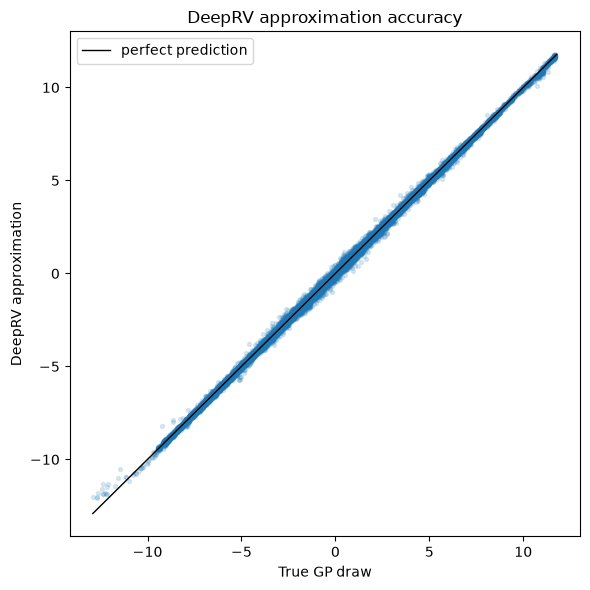

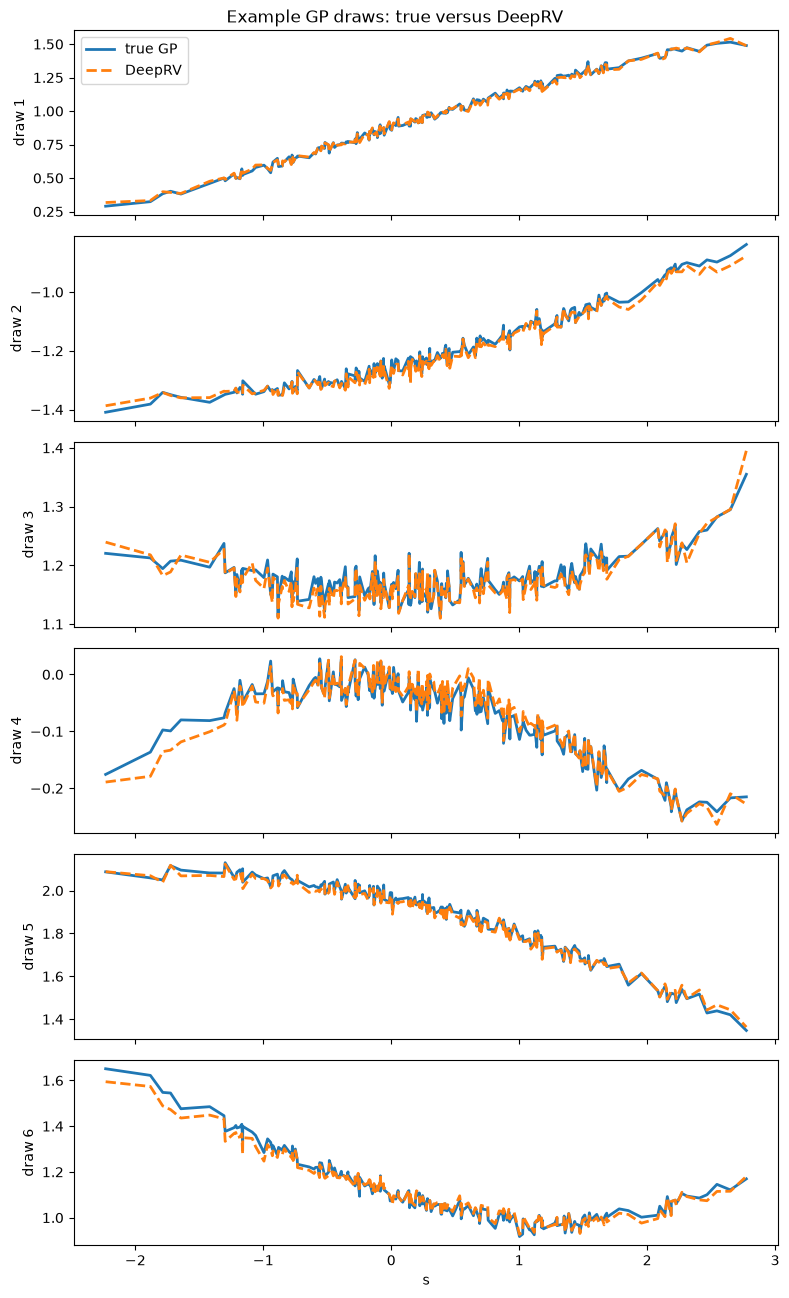

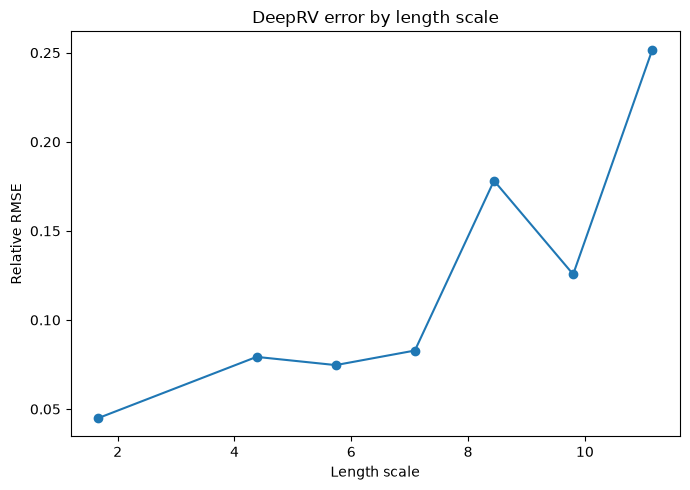

/Users/keynestay/Desktop/dl4bi/deeprv_utils.py:95: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 6000/6000 [02:01<00:00, 49.29it/s, 31 steps of size 1.41e-01. acc. prob=0.93]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        ls      3.23      1.66      2.93      0.87      5.74   3676.13      1.00
         r      4.36      2.79      3.75      0.55      8.47   5944.19      1.00
    z[0,0]     -0.79      0.35     -0.70     -1.32     -0.33   3249.77      1.00
    z[0,1]      1.30      0.59      1.24      0.36      2.23   4314.16      1.00
    z[0,2]      0.15      0.77      0.21     -1.11      1.43   8449.85      1.00
    z[0,3]     -0.01      0.99     -0.02     -1.67      1.63  11892.89      1.00
    z[0,4]     -0.06      0.97     -0.07     -1.65      1.54  11808.12      1.00
    z[0,5]     -0.00      0.99     -0.00     -1.58      1.67  12690.48      1.00
    z[0,6]      0.00      0.98      0.01     -1.61      1.60  14223.63      1.00
    z[0,7]     -0.09      0.98     -0.10     -1.65      1.56  10777.53      1.00
    z[0,8]      0.02      1.00      0.02     -1.56      1.73  13301.39      1.00
    z[0,9]     -0.01      0

/Users/keynestay/Desktop/dl4bi/deeprv_utils.py:95: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 6000/6000 [05:58<00:00, 16.73it/s, 31 steps of size 1.34e-01. acc. prob=0.94] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        ls      3.18      1.60      2.92      0.72      5.44   4838.36      1.00
         r      4.46      2.78      3.90      0.52      8.59   7316.92      1.00
    z[0,0]     -0.78      0.35     -0.70     -1.29     -0.32   3759.07      1.00
    z[0,1]      1.27      0.56      1.22      0.35      2.14   5379.94      1.00
    z[0,2]      0.14      0.74      0.19     -1.05      1.35  10866.21      1.00
    z[0,3]     -0.04      0.97     -0.04     -1.72      1.45  13778.32      1.00
    z[0,4]     -0.04      0.99     -0.05     -1.78      1.46  17616.22      1.00
    z[0,5]     -0.01      0.99     -0.02     -1.66      1.59  16481.85      1.00
    z[0,6]      0.00      0.99     -0.00     -1.52      1.72  19126.60      1.00
    z[0,7]     -0.09      1.00     -0.11     -1.75      1.55  15642.84      1.00
    z[0,8]      0.02      1.00      0.02     -1.63      1.63  16577.83      1.00
    z[0,9]     -0.00      1

,gp_time,deeprv_time,deeprv_train_time,posterior_mu_mean_mse,posterior_mu_std_mse,ls_wasserstein,r_wasserstein,gp_mcmc_time,gp_sample_time,gp_predictive_time,gp_total_time,deeprv_mcmc_time,deeprv_sample_time,deeprv_predictive_time,deeprv_total_time,dataset_size,deeprv_checkpoint_path,gp_mcmc_path,deeprv_mcmc_path,deeprv_validation_relative_rmse
0,256.328304,706.031987,5381.407763,0.000038,0.000049,0.057102,0.10618,255.779741,0.000005,0.284555,256.328304,705.183264,0.000011,0.673371,706.031987,237,results/deeprv_scaling/N_237/model.ckpt,results/deeprv_scaling/N_237/mcmc/gp_mcmc_samp...,results/deeprv_scaling/N_237/mcmc/deeprv_mcmc_...,0.013122


In [16]:
results = []
for n in dataset_sizes:

    print(f"Running N = {n}")

    metrics = run_scaling_experiment(
        dataset=datasets[n],
        priors=priors,
        seed=0,
    )

    results.append(metrics)

results = pd.DataFrame(results)

results

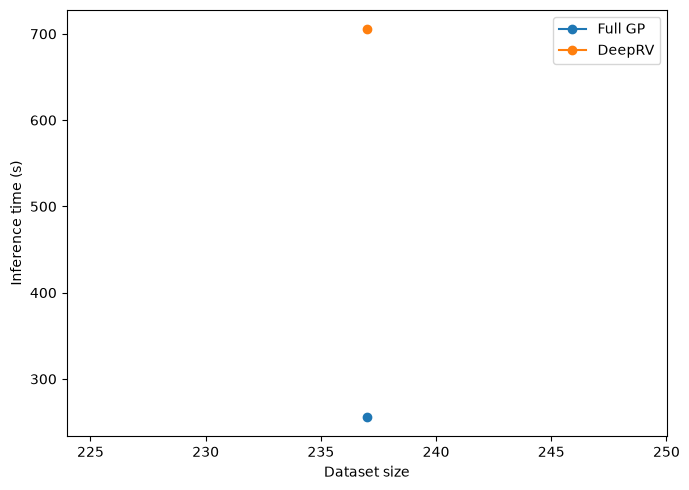

In [17]:
plt.figure(figsize=(7,5)) 

plt.plot(
    results["dataset_size"],
    results["gp_mcmc_time"],
    "-o",
    label="Full GP",
)

plt.plot(
    results["dataset_size"],
    results["deeprv_mcmc_time"],
    "-o",
    label="DeepRV",
)

plt.xlabel("Dataset size")
plt.ylabel("Inference time (s)")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
from pathlib import Path

import optax
from orbax.checkpoint import PyTreeCheckpointer

from dl4bi.core.train import TrainState
from dl4bi.vae import gMLPDeepRV
from dl4bi.vae.train_utils import generate_surrogate_decoder


def load_saved_deeprv_decoder(checkpoint_path):
    """
    Load a saved DeepRV checkpoint and rebuild the surrogate decoder.

    The saved checkpoint stores the trained model state. Depending on how Orbax
    restores it, the state may come back as a plain dictionary rather than as a
    ``TrainState`` object. This function converts that dictionary back into the
    ``TrainState`` format expected by ``generate_surrogate_decoder``.

    Parameters
    ----------
    checkpoint_path : str or pathlib.Path
        Path to the saved DeepRV checkpoint directory, for example
        ``"results/deeprv_scaling/N_237/model.ckpt"``.

    Returns
    -------
    surrogate_decoder : callable
        Decoder function used during DeepRV inference.

    state : TrainState
        Restored DeepRV training state containing the trained neural-network
        parameters.
    """
    checkpoint_path = Path(checkpoint_path)

    checkpointer = PyTreeCheckpointer()
    checkpoint = checkpointer.restore(checkpoint_path.absolute())

    restored_state = checkpoint["state"]

    nn_model = gMLPDeepRV(num_blks=2)

    # Orbax restores the saved TrainState as a dictionary, so we rebuild the
    # TrainState object manually. The optimizer is only needed to satisfy the
    # TrainState structure; we are not training further here.
    if isinstance(restored_state, dict):
        state = TrainState.create(
            apply_fn=nn_model.apply,
            params=restored_state["params"],
            kwargs=restored_state["kwargs"],
            tx=optax.identity(),
        )
    else:
        state = restored_state

    surrogate_decoder = generate_surrogate_decoder(
        state,
        nn_model,
    )

    return surrogate_decoder, state

In [24]:
def benchmark_gp_vs_deeprv_log_joint(
    s,
    y,
    priors,
    surrogate_decoder,
    *,
    seed=0,
    num_repeats=200,
):
    """
    Benchmark raw log-joint and gradient evaluation cost for GP vs DeepRV.

    This diagnostic asks a simpler question than the full MCMC experiment:

        For one fixed parameter value, is one DeepRV model evaluation actually
        cheaper than one full GP Cholesky evaluation?

    We time two things:

    1. Forward log-joint evaluation:
       Computes the log prior plus Bernoulli log likelihood.

    2. Gradient evaluation:
       Computes the log-joint and its gradients. This is important because
       NUTS/HMC repeatedly needs gradients during leapfrog steps.

    Parameters
    ----------
    s : jax.Array
        Input locations with shape ``(N, input_dim)``.

    y : jax.Array
        Bernoulli observations with shape ``(N,)``.

    priors : dict
        Kernel hyperparameter priors. Expected keys are ``"ls"`` and ``"r"``.

    surrogate_decoder : callable
        Trained DeepRV decoder returned by ``train_deeprv``.

    seed : int
        Random seed used to choose one test value of ``ls``, ``r``, and ``z``.

    num_repeats : int
        Number of repeated evaluations used for timing. Larger values give
        more stable timings.

    Returns
    -------
    pandas.DataFrame
        Table comparing GP and DeepRV forward/gradient evaluation times.
    """
    rng = random.key(seed)
    rng_ls, rng_r, rng_z = random.split(rng, 3)

    n = s.shape[0]

    # Draw one representative parameter setting from the prior.
    ls0 = priors["ls"].sample(rng_ls)
    r0 = priors["r"].sample(rng_r)
    z0 = dist.Normal().sample(rng_z, sample_shape=(n,))

    def gp_log_joint(ls, r, z):
        """
        Exact GP log joint for one parameter value.

        This includes:
        - prior log density for ls and r;
        - standard normal log density for z;
        - Bernoulli likelihood using mu = chol(K) @ z.
        """
        K = rbf(s, s, r, ls) + 5e-4 * jnp.eye(n)
        L = jnp.linalg.cholesky(K)
        mu = L @ z
        p = jax.nn.sigmoid(mu)

        log_prior = (
            priors["ls"].log_prob(ls)
            + priors["r"].log_prob(r)
            + dist.Normal().log_prob(z).sum()
        )

        log_lik = dist.Bernoulli(probs=p).log_prob(y).sum()

        return log_prior + log_lik

    def deeprv_log_joint(ls, r, z):
        """
        DeepRV approximate log joint for one parameter value.

        This uses the trained neural surrogate instead of the GP Cholesky:
        mu_hat = DeepRV(theta, z).
        """
        z_batch = z[None, :]

        mu_hat = surrogate_decoder(
            z_batch,
            jnp.array([ls, r]),
            s=s,
        )

        mu_hat = jnp.squeeze(mu_hat)
        p = jax.nn.sigmoid(mu_hat)

        log_prior = (
            priors["ls"].log_prob(ls)
            + priors["r"].log_prob(r)
            + dist.Normal().log_prob(z).sum()
        )

        log_lik = dist.Bernoulli(probs=p).log_prob(y).sum()

        return log_prior + log_lik

    # JIT compile forward functions.
    gp_forward = jax.jit(gp_log_joint)
    deeprv_forward = jax.jit(deeprv_log_joint)

    # JIT compile value-and-gradient functions.
    # argnums=(0, 1, 2) means we differentiate with respect to ls, r, and z.
    gp_grad = jax.jit(jax.value_and_grad(gp_log_joint, argnums=(0, 1, 2)))
    deeprv_grad = jax.jit(jax.value_and_grad(deeprv_log_joint, argnums=(0, 1, 2)))

    # Warm up once so compilation time is not included in the benchmark.
    _ = jax.block_until_ready(gp_forward(ls0, r0, z0))
    _ = jax.block_until_ready(deeprv_forward(ls0, r0, z0))
    _ = jax.block_until_ready(gp_grad(ls0, r0, z0))
    _ = jax.block_until_ready(deeprv_grad(ls0, r0, z0))

    def time_function(fn, label):
        """
        Time repeated calls to a JAX function after compilation.
        """
        start = time.perf_counter()

        out = None
        for _ in range(num_repeats):
            out = fn(ls0, r0, z0)

        # Force JAX to finish all queued work before stopping the timer.
        out = jax.block_until_ready(out)

        elapsed = time.perf_counter() - start

        return {
            "method": label,
            "num_repeats": num_repeats,
            "total_seconds": elapsed,
            "seconds_per_eval": elapsed / num_repeats,
        }

    rows = [
        time_function(gp_forward, "GP forward log_joint"),
        time_function(deeprv_forward, "DeepRV forward log_joint"),
        time_function(gp_grad, "GP value_and_grad"),
        time_function(deeprv_grad, "DeepRV value_and_grad"),
    ]

    return pd.DataFrame(rows)

In [25]:
surrogate_decoder_237, state_237 = load_saved_deeprv_decoder(
    "results/deeprv_scaling/N_237/model.ckpt"
)

s_237, y_237 = generate_survival_data(datasets[250])

timing_237 = benchmark_gp_vs_deeprv_log_joint(
    s_237,
    y_237,
    priors,
    surrogate_decoder_237,
    seed=0,
    num_repeats=200,
)

timing_237

/opt/anaconda3/envs/dl4bi-env/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:925: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


,method,num_repeats,total_seconds,seconds_per_eval
0,GP forward log_joint,200,0.029828,0.000149
1,DeepRV forward log_joint,200,0.176936,0.000885
2,GP value_and_grad,200,0.138630,0.000693
3,DeepRV value_and_grad,200,0.399683,0.001998
